gamma =  0.0
kappa =  0.0
E11 = 0.0  micros
E12 = 0.0  micros
E22 = 0.0  micros
E11-E22 = 0.0  micros
E_bar = 0.0  micros
SVG QR code saved to /Users/surya/Science_Project_Yr3_QR_code/Test_Images/qr_code_ref.svg


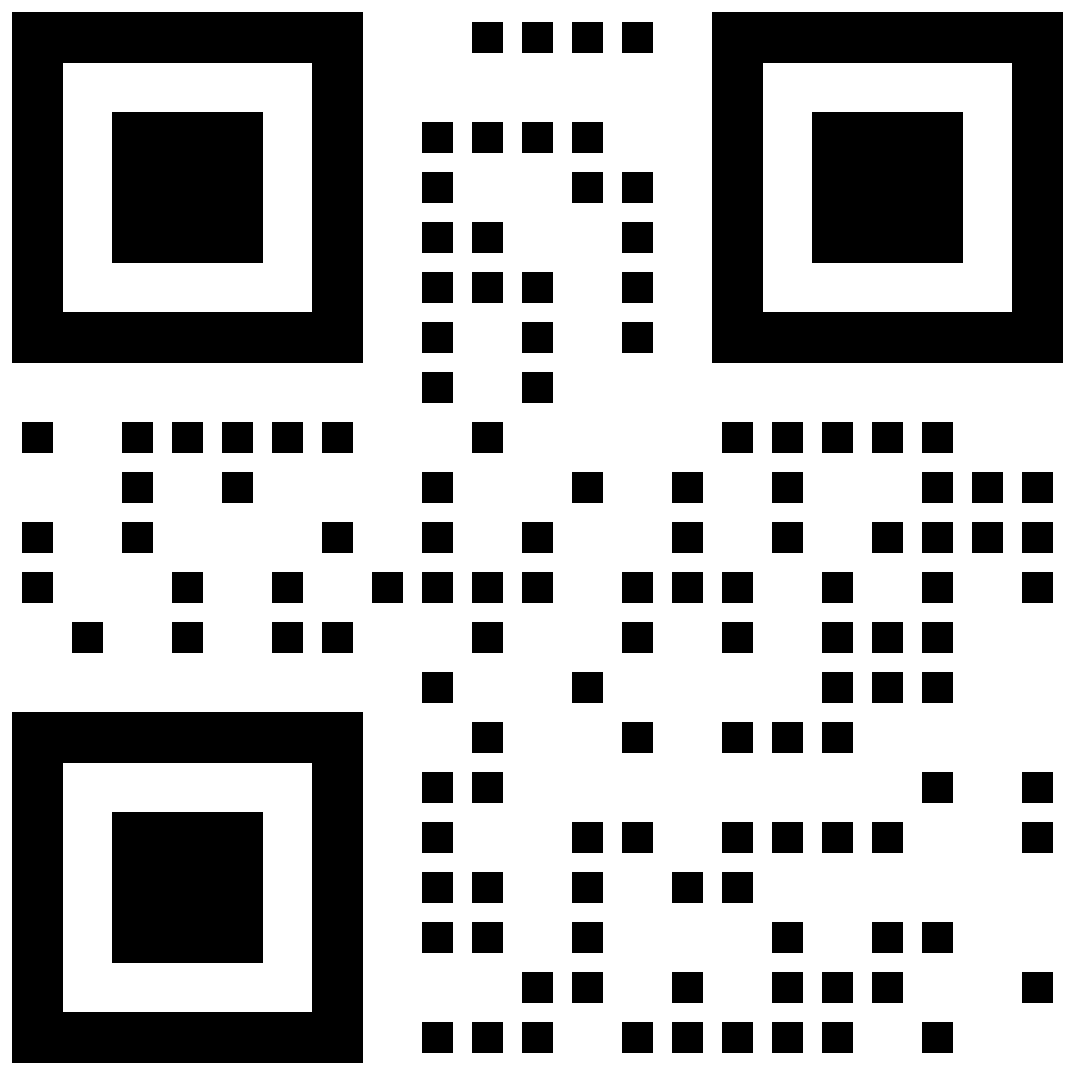

PNG saved to /Users/surya/Science_Project_Yr3_QR_code/Test_Images/qr_code_ref.png: 6047×6047 px at 3200 DPI (~48.0 mm each side).


In [ ]:
"""
Code Name: Python Code for Creating QR Codes

Author: Surya S. Vel

Date: 2/17/2026

Version: 6
"""

#******************
# Import Libraries
#******************

import segno
import math
import svgwrite
from PIL import Image, ImageDraw
from IPython.display import display, SVG
import matplotlib.pyplot as plt
import numpy as np
import cairosvg
from IPython.display import Image as IPyImage
from scipy.linalg import sqrtm,logm, expm

# --- Configuration ---
# Data to be encoded
data = "123456789.123456.123"
# Where to store the image locally
image_path = '/Users/surya/Science_Project_Yr3_QR_code/Test_Images/'

# Type of QR codes (version 1 has the least amount of data modules)
version = 1
error_correction = 'L'

#-----------------------------------------------------------
#  Function for calculating the strains
#-----------------------------------------------------------
def calculate_strains(A11,A12,A21,A22):

    F = np.array([[A11,A12],[A21,A22]])

    # print('F =',F)

    J = np.linalg.det(F)
    if J <= 0:
        print('Error: Jacobian J =', J, ' (negative)')
        print('Corresponding A matrix = \n', F)
    
    # Factor out dilatational deformation
    F = F/(math.sqrt(J))

    # Right Cauchy Green deformation tensor
    C = F.T@F

    # Define identity matrix I_matrix
    I_matrix = np.identity(2)

    # Calculate the strain tensor
    E = logm(C)*(1/2) # Logarithmic or Hencky strain
    E_bar = math.sqrt(2*np.trace(E@E))

    # Extract components of the strain tensor
    E11 = E[0][0]
    E12 = E[0][1]
    E22 = E[1][1]

    return(E11,E12,E22,E_bar)

#-----------------------------------------------------------
# Specify whether to generate reference or deformed QR code
# Set to 0 for no deformation, 1 for deformation
#-----------------------------------------------------------
DEFORM = 0

#-----------------------------------------------------------
# Affine mapping parameters for generating deformed QR code
#-----------------------------------------------------------
gamma = 0.0
print("gamma = ",gamma)
kappa = math.tan(gamma)
print("kappa = ",kappa)
A11 =  1.0
A12 =  kappa
A21 =  0
A22 =  1.0

E11,E12,E22,E_bar = calculate_strains(A11,A12,A21,A22)
print('E11 =',f"{E11*1E6:.1f}",' micros')
print('E12 =',f"{E12*1E6:.1f}",' micros')
print('E22 =',f"{E22*1E6:.1f}",' micros')
print('E11-E22 =',f"{(E11-E22)*1E6:.1f}",' micros')
print('E_bar =',f"{E_bar*1E6:.1f}",' micros')

#-----------------------------------------------------------
#   Choose physical size & DPI of PNG image 
#-----------------------------------------------------------
side_mm = 48.0   # desired printed side length in millimeters (square)
dpi = 3200        # desired output DPI

#-----------------------------------------------------------
# Base scale for module size (SVG)
#-----------------------------------------------------------
scale = 50.0 

#-----------------------------------------------------------
# Tiny stroke to hide anti-alias seams between adjacent quads
#-----------------------------------------------------------
STROKE_PX = 1.0    # ~subpixel at high DPI

#-----------------------------------------------------------
#  Function for affine mapping of points
#-----------------------------------------------------------
def affine_mapping(A11,A12,A21,A22,pts):
    for n in range(len(pts)):
        # Read the x and y coordinates for each row
        x = pts[n][0]
        y = pts[n][1]
         
	    # Perform affine mapping
        x_prime = A11*x + A12*y
        y_prime = A21*x + A22*y

        # Update the coordinates
        pts[n][0] = x_prime
        pts[n][1] = y_prime
    return(pts)

#-----------------------------------------------------------
#  Reset affine mapping parameters for no deformation
#-----------------------------------------------------------
if DEFORM == 0:
    A11 = 1.0
    A12 = 0
    A21 = 0
    A22 = 1.0  
    svg_filename = 'qr_code_ref.svg'
    png_filename = 'qr_code_ref.png' 
else:
    svg_filename = 'qr_code_def.svg'
    png_filename = 'qr_code_def.png'

#-----------------------------------------------------------
#  Generate QR code and save as SVG file  
#-----------------------------------------------------------

# --- Scaling factor for square data modules (0 < factor <= 1) ---
module_scale_factor = 0.6  # 1 = full module size, 0.8 = 80% of module etc...

# --- Create QR code ---
qr = segno.make(data, version=version, error=error_correction)
matrix = qr.matrix
size = len(matrix)

# --- Collect polygons after affine transform ---
all_polys = []   # list of Nx2 numpy arrays

# Generate quadrilaterals for each QR code region 
for row, line in enumerate(matrix):
    for col, module in enumerate(line):
        if module:
            # Determine if module is part of a position marker
            in_top_left = row < 7 and col < 7
            in_top_right = row < 7 and col >= size - 7
            in_bottom_left = row >= size - 7 and col < 7

            if in_top_left or in_top_right or in_bottom_left:
                # Full-size square for position markers
                corner_pts = np.array([
                    [col * scale, row * scale],  # top-left
                    [(col + 1) * scale, row * scale],  # top-right
                    [(col + 1) * scale, (row + 1) * scale],  # bottom-right
                    [col * scale, (row + 1) * scale]  # bottom-left
                    ])
            else:
                # Scaled square for data modules
                module_size = scale * module_scale_factor
                offset = (scale - module_size) / 2
                corner_pts = np.array([
                    [col * scale + offset, row * scale + offset],  # top-left
                    [col * scale + offset + module_size, row * scale + offset],  # top-right
                    [col * scale + offset + module_size, row * scale + offset + module_size],  # bottom-right
                    [col * scale + offset, row * scale + offset + module_size]  # bottom-left
                   ])

            mapped_pts = affine_mapping(A11,A12,A21,A22,corner_pts)
            all_polys.append(np.array(mapped_pts))

# --- Compute bounding box of all polygons ---
all_points = np.vstack(all_polys)  # stack all Nx2 into one array
xmin, ymin = all_points.min(axis=0)
xmax, ymax = all_points.max(axis=0)

# --- Translation so (xmin,ymin) -> (0,0) ---
margin = scale/4
translation = np.array([-xmin+margin , -ymin+margin])

# --- Resize SVG canvas ---
width = xmax - xmin + 2*margin 
height = ymax - ymin+ 2*margin 
dwg = svgwrite.Drawing(
    image_path + svg_filename,
    size=(f"{width}px", f"{height}px"),
    profile='tiny'
)

# --- Add translated polygons to SVG ---
for poly in all_polys:
    poly_translated = (poly + translation).tolist()
    dwg.add(dwg.polygon(points=poly_translated, fill='black',stroke='black',stroke_width=STROKE_PX))

dwg.save()
print(f"SVG QR code saved to {image_path+svg_filename}")

# Display inline
display(SVG(filename=image_path + svg_filename))

#-----------------------------------------------------------
#  Save the file as a PNG file
#-----------------------------------------------------------

# ---- Export PNG with matching mm size at the chosen DPI ----
# pixels = inches * dpi = (mm / 25.4) * dpi
side_px = int(round(side_mm / 25.4 * dpi))

cairosvg.svg2png(
    url=image_path + svg_filename,
    write_to=image_path + png_filename,
    dpi=dpi,
    output_width=side_px,
    output_height=side_px,
    background_color='white'
)

png_outfile = image_path + png_filename

# Open with Pillow and re-save with correct DPI tag
im = Image.open(png_outfile)
im.save(png_outfile, dpi=(dpi, dpi))

print(f"PNG saved to {image_path+png_filename}: {side_px}×{side_px} px at {dpi} DPI (~{side_mm} mm each side).")

gamma =  0
kappa =  0.0


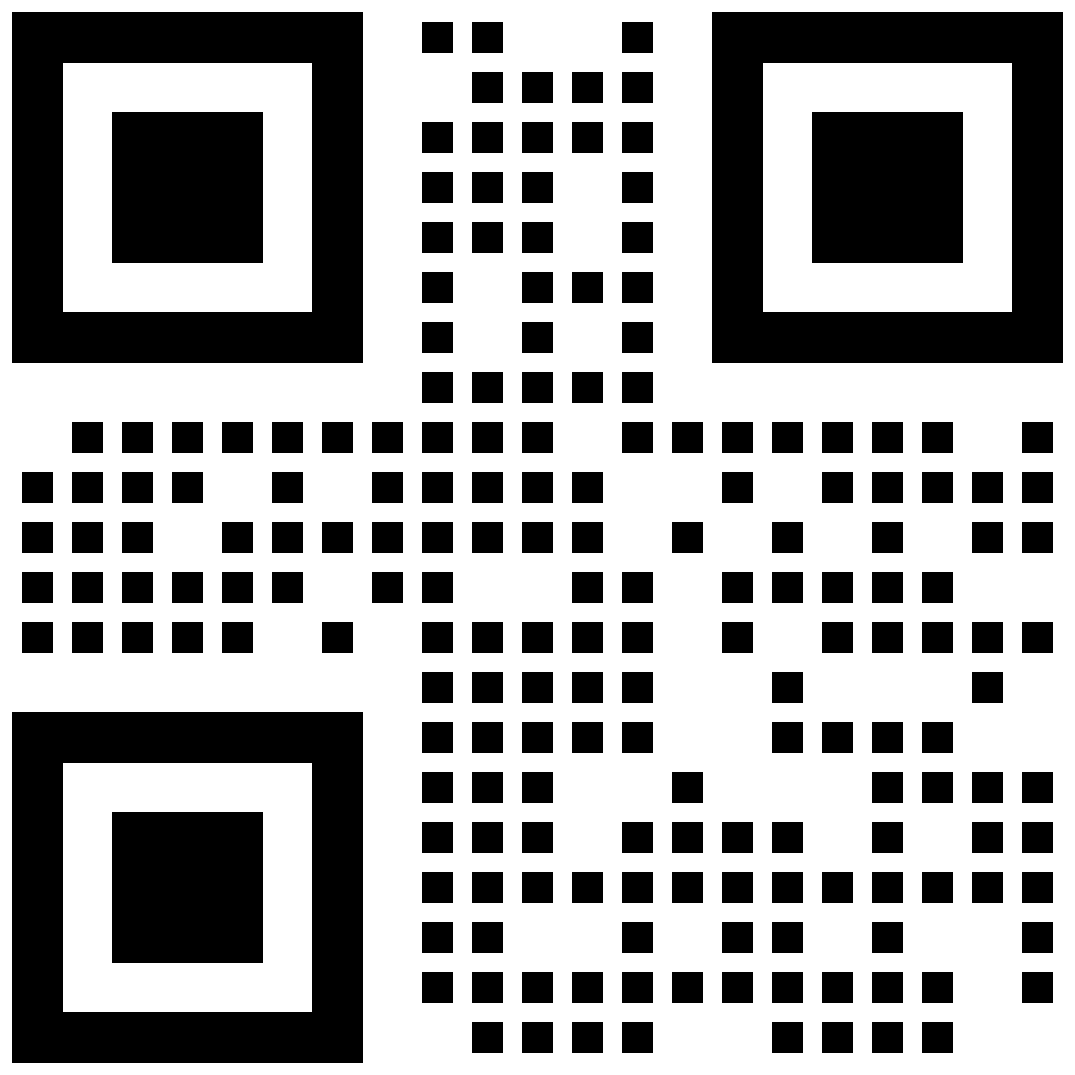

DONE


In [24]:
#-----------------------------------------------------
#    MAX-DENSITY QR-style pattern (FIXED VERSION)
#-----------------------------------------------------

import segno
import math
import svgwrite
from PIL import Image
from IPython.display import display, SVG
import numpy as np
import cairosvg
from scipy.linalg import logm

# --- Configuration ---
data = "dummy"
image_path = '/Users/surya/Science_Project_Yr3_QR_code/Test_Images/'
version = 1
error_correction = 'L'

#-----------------------------------------------------------
# strain calculation
#-----------------------------------------------------------
def calculate_strains(A11,A12,A21,A22):

    F = np.array([[A11,A12],[A21,A22]])
    J = np.linalg.det(F)

    F = F/(math.sqrt(J))
    C = F.T@F

    E = logm(C)*(1/2)
    E_bar = math.sqrt(2*np.trace(E@E))

    return E[0][0],E[0][1],E[1][1],E_bar

# deformation
DEFORM = 0
gamma = 0
print("gamma = ",gamma)
kappa = math.tan(gamma)
print("kappa = ",kappa)
A11 =  1.0
A12 =  kappa
A21 =  0
A22 =  1.0
# output
side_mm = 48.0
dpi = 2400

scale = 50.0
module_scale_factor = 0.6   # IMPORTANT
STROKE_PX = 1.0

#-----------------------------------------------------------
def affine_mapping(A11,A12,A21,A22,pts):

    for n in range(len(pts)):
        x,y = pts[n]
        pts[n][0] = A11*x + A12*y
        pts[n][1] = A21*x + A22*y

    return pts

#-----------------------------------------------------------
# Generate QR layouts
#-----------------------------------------------------------

# Two DIFFERENT QR codes
qr1 = segno.make("AAAAAAAAAAAA", version=version, error=error_correction)
qr2 = segno.make("BBBBBBBBBBBB", version=version, error=error_correction)

mat1 = np.array(list(qr1.matrix), dtype=bool)
mat2 = np.array(list(qr2.matrix), dtype=bool)

size = len(mat1)

#-----------------------------------------------------------
# Detect FUNCTIONAL modules automatically
#-----------------------------------------------------------

# Functional modules are identical between different QR codes
functional_mask = (mat1 == mat2)

#-----------------------------------------------------------
# Build MAX-DENSITY matrix
#-----------------------------------------------------------

matrix = np.ones_like(mat1, dtype=bool)

# Keep functional regions exactly as original
matrix[functional_mask] = mat1[functional_mask]


#-----------------------------------------------------------
# build polygons
#-----------------------------------------------------------
all_polys = []

for row,line in enumerate(matrix):

    for col,module in enumerate(line):

        if module:

            in_top_left = row < 7 and col < 7
            in_top_right = row < 7 and col >= size - 7
            in_bottom_left = row >= size - 7 and col < 7

            if in_top_left or in_top_right or in_bottom_left:

                # FULL SIZE finder squares
                corner_pts = np.array([
                    [col*scale,row*scale],
                    [(col+1)*scale,row*scale],
                    [(col+1)*scale,(row+1)*scale],
                    [col*scale,(row+1)*scale]
                ])

            else:

                # SHRUNK data squares (prevents merging)
                module_size = scale * module_scale_factor
                offset = (scale - module_size)/2

                corner_pts = np.array([
                    [col*scale+offset,row*scale+offset],
                    [col*scale+offset+module_size,row*scale+offset],
                    [col*scale+offset+module_size,row*scale+offset+module_size],
                    [col*scale+offset,row*scale+offset+module_size]
                ])

            mapped_pts = affine_mapping(A11,A12,A21,A22,corner_pts)
            all_polys.append(np.array(mapped_pts))

#-----------------------------------------------------------
# bounding box
#-----------------------------------------------------------
all_points = np.vstack(all_polys)

xmin,ymin = all_points.min(axis=0)
xmax,ymax = all_points.max(axis=0)

margin = scale/4
translation = np.array([-xmin+margin,-ymin+margin])

width = xmax-xmin+2*margin
height = ymax-ymin+2*margin

dwg = svgwrite.Drawing(
    image_path+'qr_code_def.svg',
    size=(f"{width}px",f"{height}px"),
    profile='tiny'
)

for poly in all_polys:

    poly_translated = (poly+translation).tolist()

    dwg.add(
        dwg.polygon(
            points=poly_translated,
            fill='black',
            stroke='black',
            stroke_width=STROKE_PX
        )
    )

dwg.save()

display(SVG(filename=image_path+'qr_code_def.svg'))

#-----------------------------------------------------------
# export PNG
#-----------------------------------------------------------
side_px = int(round(side_mm/25.4*dpi))

cairosvg.svg2png(
    url=image_path+'qr_code_def.svg',
    write_to=image_path+'qr_code_def.png',
    dpi=dpi,
    output_width=side_px,
    output_height=side_px,
    background_color='white'
)

im = Image.open(image_path+'qr_code_def.png')
im.save(image_path+'qr_code_def.png', dpi=(dpi,dpi))

print("DONE")


gamma =  0
kappa =  0.0


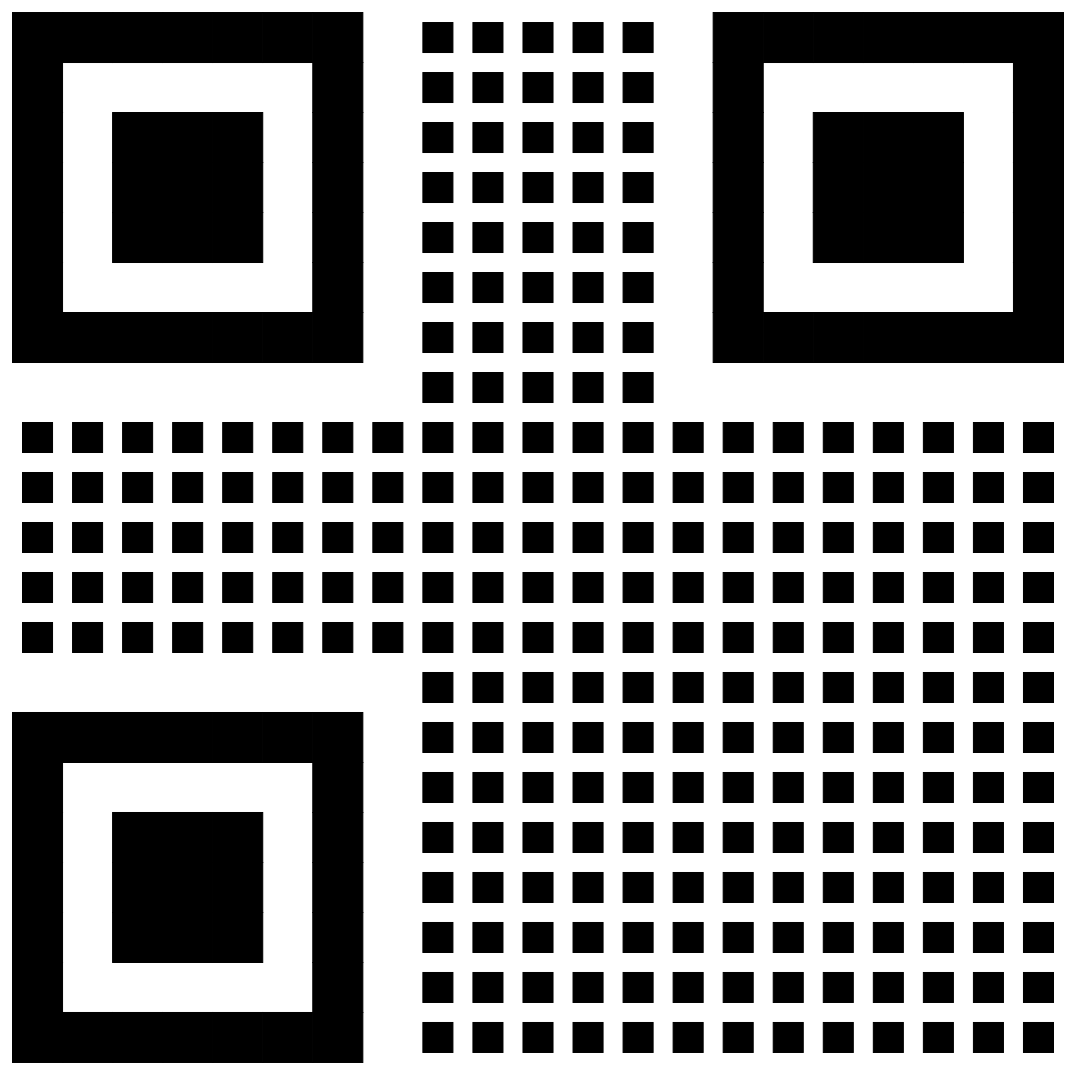

DONE


In [30]:
#-----------------------------------------------------
#    MAX-DENSITY QR-style pattern (FIXED VERSION)
#-----------------------------------------------------

import segno
import math
import svgwrite
from PIL import Image
from IPython.display import display, SVG
import numpy as np
import cairosvg
from scipy.linalg import logm

# --- Configuration ---
data = "dummy"
image_path = '/Users/surya/Science_Project_Yr3_QR_code/Test_Images/'
version = 1
error_correction = 'L'

#-----------------------------------------------------------
# strain calculation
#-----------------------------------------------------------
def calculate_strains(A11,A12,A21,A22):

    F = np.array([[A11,A12],[A21,A22]])
    J = np.linalg.det(F)

    F = F/(math.sqrt(J))
    C = F.T@F

    E = logm(C)*(1/2)
    E_bar = math.sqrt(2*np.trace(E@E))

    return E[0][0],E[0][1],E[1][1],E_bar

# deformation
DEFORM = 1
gamma = 0
print("gamma = ",gamma)
kappa = math.tan(gamma)
print("kappa = ",kappa)
A11 =  1.001
A12 =  kappa
A21 =  0
A22 =  1.0

# output
side_mm = 48.0
dpi = 2400

scale = 50.0
module_scale_factor = 0.6   # IMPORTANT
STROKE_PX = 1.0

#-----------------------------------------------------------
def affine_mapping(A11,A12,A21,A22,pts):

    for n in range(len(pts)):
        x,y = pts[n]
        pts[n][0] = A11*x + A12*y
        pts[n][1] = A21*x + A22*y

    return pts

#-----------------------------------------------------------
# Generate QR layout (FIXED with Separators)
#-----------------------------------------------------------
qr = segno.make(data, version=version, error=error_correction)

original_matrix = np.array(list(qr.matrix), dtype=bool)
size = len(original_matrix)

# Start with a fully filled data region
matrix = np.ones_like(original_matrix, dtype=bool)

for row in range(size):
    for col in range(size):
        # We define an 8x8 area (7 for finder + 1 for separator)
        in_top_left_zone = row < 8 and col < 8
        in_top_right_zone = row < 8 and col >= size - 8
        in_bottom_left_zone = row >= size - 8 and col < 8

        # If we are inside the 'eye' zones, use the original QR's pattern
        # This preserves both the black finder AND the white separator
        if in_top_left_zone or in_top_right_zone or in_bottom_left_zone:
            matrix[row, col] = original_matrix[row, col]

#-----------------------------------------------------------
# build polygons
#-----------------------------------------------------------
all_polys = []

for row, line in enumerate(matrix):
    for col, module in enumerate(line):
        if module:
            # Re-check zones to decide if we draw a full square or a shrunk module
            # We use 7x7 here so ONLY the actual finder bits are full-size
            is_finder_eye = (row < 7 and col < 7) or \
                            (row < 7 and col >= size - 7) or \
                            (row >= size - 7 and col < 7)

            if is_finder_eye:
                # FULL SIZE finder squares
                corner_pts = np.array([
                    [col*scale, row*scale],
                    [(col+1)*scale, row*scale],
                    [(col+1)*scale, (row+1)*scale],
                    [col*scale, (row+1)*scale]
                ])
            else:
                # SHRUNK data squares for the filled grid
                module_size = scale * module_scale_factor
                offset = (scale - module_size) / 2

                corner_pts = np.array([
                    [col*scale+offset, row*scale+offset],
                    [col*scale+offset+module_size, row*scale+offset],
                    [col*scale+offset+module_size, row*scale+offset+module_size],
                    [col*scale+offset, row*scale+offset+module_size]
                ])

            mapped_pts = affine_mapping(A11, A12, A21, A22, corner_pts)
            all_polys.append(np.array(mapped_pts))
#-----------------------------------------------------------
# bounding box
#-----------------------------------------------------------
all_points = np.vstack(all_polys)

xmin,ymin = all_points.min(axis=0)
xmax,ymax = all_points.max(axis=0)

margin = scale/4
translation = np.array([-xmin+margin,-ymin+margin])

width = xmax-xmin+2*margin
height = ymax-ymin+2*margin

dwg = svgwrite.Drawing(
    image_path+'qr_code_def.svg',
    size=(f"{width}px",f"{height}px"),
    profile='tiny'
)

for poly in all_polys:

    poly_translated = (poly+translation).tolist()

    dwg.add(
        dwg.polygon(
            points=poly_translated,
            fill='black',
            stroke='black',
            stroke_width=STROKE_PX
        )
    )

dwg.save()

display(SVG(filename=image_path+'qr_code_def.svg'))

#-----------------------------------------------------------
# export PNG
#-----------------------------------------------------------
side_px = int(round(side_mm/25.4*dpi))

cairosvg.svg2png(
    url=image_path+'qr_code_def.svg',
    write_to=image_path+'qr_code_def.png',
    dpi=dpi,
    output_width=side_px,
    output_height=side_px,
    background_color='white'
)

im = Image.open(image_path+'qr_code_def.png')
im.save(image_path+'qr_code_def.png', dpi=(dpi,dpi))

print("DONE")
